# Activity: Dijkstra's Shortest Path Algorithm
In this activity, you will play around with an implementation of Dijkstra's Shortest Path algorithm for finding shortest paths from a single source to all other vertices in a weighted graph. The time complexity of Dijkstra's algorithm is $\mathcal{O}((|\mathcal{V}| + |\mathcal{E}|)\cdot\log|\mathcal{V}|)$, where $|\mathcal{E}|$ is the number of edges and $|\mathcal{V}|$ is the number of vertices in the graph (where we use a priority queue to keep track of nodes to explore).

> __Problem overview:__ Suppose we are planning a multistep task that must be completed for a complex project, e.g., constructing a new production process. At our planning meeting, we brainstorm two different ideas about how to accomplish the overall task, one idea involves only five steps, but has a few costly steps. The second idea involves six steps, and several of the steps are less expensive. Which idea (path) should we choose? This is a classic shortest path problem!

We'll build a small example, run the algorithm, and visualize the resulting paths so you can see how the shortest path is determined.

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [32]:
include(joinpath(@__DIR__, "Include.jl"));

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

### Constants
Let's define some constants that will be used throughout the notebook. See the comment for a description of each constant, what it represents, its value, units, etc.

In [33]:
# We are going to plot the path through a graph, so let's provide the coordinates for each node, i.e., the layout
# This layout looks like our schematic but you can rearrange this if you want!
node_coordinates = [

    # source node (project start)
    10.0 10.0 ; # 1 source node s (x,y) coordinates
    11.0 10.0 ; # 2 
    11.0 11.0 ; # 3
    13.0 11.0 ; # 4
    13.0 10.0 ; # 5
    11.0 9.0  ; # 6 
    12.0 9.0  ; # 7
    13.0 9.0  ; # 8
    14.0 10.0  ; # 9 project completion
];

### Implementations
Below are helper routines used in this notebook. The `flow(...)` function turns the predecessor map from the shortest-path solution into a per-edge flow array so we can highlight the edges that lie on the shortest paths.

We'll also provide a few small utility functions to parse the edge list and build the graph model. The code cells below include thorough docstrings and comments — skim the docstrings if you want the quick idea, or read the comments for implementation details.

In [34]:
"""
    function flow(graph::MySimpleDirectedGraphModel, distances::Dict{Int64, Float64}, 
        previous::Dict{Int64, Union{Nothing,Int64}})::Array{Float64,1}

Computes the flow through the graph based on the shortest path tree defined by `distances` and `previous`.

This version ignores nodes whose predecessor is `nothing` (unreachable or the source), and it safely
handles cases where an inverse-edge mapping may be missing.

### Arguments
- `graph`: The graph model instance.
- `distances`: A dictionary mapping each node to its distance from the source.
- `previous`: A dictionary mapping each node to its predecessor in the shortest path tree.

### Returns
- An array representing the flow through the graph.
"""
function flow(graph::MySimpleDirectedGraphModel, distances::Dict{Int64, Float64}, 
    previous::Dict{Int64, Union{Nothing,Int64}})::Array{Float64,1}
    
    # initialize -
    number_of_nodes = length(graph.nodes);
    number_of_edges = length(graph.edges);
    flow = zeros(Float64, number_of_edges); # initialize the flow array with zeros

    # create a inverse edge dictionary -
    inversedgemap = Dict{Tuple{Int64, Int64}, Int64}();
    for (k, v) ∈ graph.edgesinverse
        inversedgemap[v] = k;
    end

    # iterate over the nodes (skip the source at index 1)
    nodes = range(2, stop=number_of_nodes) |> collect |> reverse;
    for node ∈ nodes
        p = previous[node]; # this is a connection or nothing

        # skip nodes with no predecessor (unreachable or the source)
        if p === nothing
            continue
        end

        key = (p, node)
        if haskey(inversedgemap, key)
            i = inversedgemap[key]; # this is the edge id
            flow[i] = 1.0;
        else
            # defensive: predecessor entry exists but inverse-edge mapping missing
            @warn "Inverse edge not found for predecessor pair" node=node predecessor=p
            continue
        end
    end

    # return -
    return flow;
end;

In [35]:
"""
    function reconstruct_path(pmap, node)

Reconstructs the shortest path from the source to a given node using the predecessor map.

### Arguments
- `pmap`: A dictionary mapping each node to its predecessor in the shortest path tree.
- `node`: The target node for which to reconstruct the path.

### Returns
- An array representing the path from source to the target node.
"""
function reconstruct_path(pmap, node)
    path = Int[]
    cur = node
    while cur !== nothing
        push!(path, cur)
        cur = get(pmap, cur, nothing)
    end
    reverse!(path)
    return path
end;

## Task 1: Build a project task graph
In this task, we will build a simple directed graph representing the steps in a project, where each edge has a weight that represents the cost of completing that step. The graph will be represented as an adjacency list.

Edges are stored in `data/Production-Process.edgelist` with fields: source, target, cost. We'll parse the file into `MyGraphEdgeModel` instances and then build a directed graph model for the shortest path calculation using Dijkstra's algorithm.

<div>
    <center>
        <img src="figs/Fig-Branch-Schematic.svg" width="480"/>
    </center>
</div>

The graph and weights are specified in the `data/Production-Process.edgelist` file, where each record is defined as:
> __Records__: Each record in our edgelist file has the comma separated fields: `source,` `target,` `cost.` The `source` field is the id for the source node, e.g., `1`, the `target` field is the target node id, the `cost` is the cost of assigning the source node to the target node, i.e., the cost (monetary, time, etc.) of completing the task.

Ok, so now let's setup our edge parser __callback function__:

In [36]:
"""
    function edgerecordparser(record::String, delim::Char=',') -> Tuple{Int, Int, Float64} | Nothing

This method is called to parse a single edge record from the edgelist file. It gets called once for each record in the file. 
The function splits the record into fields based on the specified delimiter and extracts the source node, target node, and cost (weight) of the edge. 
It returns a tuple containing these values. If the record does not have the expected number of fields, it returns `nothing`.

### Arguments
- `record`: The edge record string to parse.
- `delim`: The delimiter used to split the record.

### Returns
- A tuple containing the source node, target node, and cost of the edge, or `nothing` if the record is invalid.
"""
function edgerecordparser(record::String, delim::Char=',')

    # record (three fields)
    # source, target, cost

    fields = split(record, delim) # this assumes a record of the form "source,target,weight"
    if length(fields) < 3 # we have 3 fields
        return nothing
    end

    # get my data -
    source = parse(Int, fields[1]) # source id
    target = parse(Int, fields[2]) # target id
    cost = parse(Float64, fields[3]) # edge weight
    
    # return a tuple -
    return (source, target, cost) # we are ignoring the capacity constraints
end;

Next, let's set the path to the edge list file in the `path_to_edge_file::String` variable:

In [37]:
path_to_edge_file = joinpath(_PATH_TO_DATA, "Production-Process.edgelist"); # this points to the graph shown above

Next, construct a dictionary [of `MyEdgeModel` instances](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MyGraphEdgeModel) which stores the data for the edges. Let's save our edge models in the `myedgemodels::Dict{Int64, MyGraphEdgeModel}` dictionary. 

The keys in the edge dictionary will be the edge ids (which we can assume are unique), and the values will be the corresponding `MyGraphEdgeModel` instances. Here, we've used the line index in the edgefile as the edge id.

In [38]:
myedgemodels = MyGraphEdgeModels(path_to_edge_file, edgerecordparser, delim=',', comment='#')

Dict{Int64, MyGraphEdgeModel} with 9 entries:
  0 => MyGraphEdgeModel(0, 1, 2, 1.0)
  4 => MyGraphEdgeModel(4, 4, 5, 2.0)
  5 => MyGraphEdgeModel(5, 2, 6, 2.0)
  6 => MyGraphEdgeModel(6, 6, 7, 2.0)
  2 => MyGraphEdgeModel(2, 2, 3, 6.0)
  7 => MyGraphEdgeModel(7, 7, 8, 2.0)
  8 => MyGraphEdgeModel(8, 8, 5, 2.0)
  3 => MyGraphEdgeModel(3, 3, 4, 8.0)
  1 => MyGraphEdgeModel(1, 5, 9, 1.0)

Finally, we can build a graph instance. Since this is a directed graph, we'll construct [a `MySimpleDirectedGraphModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MySimpleDirectedGraphModel) using [a `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build). Let's save our graph model in the `directedgraphmodel::MySimpleDirectedGraphModel` variable.

In [39]:
directedgraphmodel = build(MySimpleDirectedGraphModel, myedgemodels);

## Task 2: Compute Shortest Paths
In this task, we'll compute the best (lowest cost) production planning paths.

This is a simple test case, so we can look at the edge weights and guess the shortest paths using our intuition, without running the algorithm. Let's do that so we can check if what we think should happen, actually happens.

To compute shortest paths we call `findshortestpath(...)` with three main inputs: the graph model, the start node, and the algorithm choice (here `DijkstraAlgorithm()`).

The function returns a distances dictionary (`d`) mapping each node to its shortest distance from the start, and a predecessors dictionary (`p`) mapping each node to its predecessor on the shortest path.

We'll run Dikjstra on our graph and then visualize which edges lie on the shortest paths from the source.

In [40]:
(d,p) = let
    
    # initialize -
    startnode = directedgraphmodel.nodes[1];

    # run the Dijkstra Algorithm algorithm -
    (d,p) = findshortestpath(directedgraphmodel, startnode, algorithm = DijkstraAlgorithm());

    (d,p) # return
end;

In [41]:
p

Dict{Int64, Union{Nothing, Int64}} with 8 entries:
  5 => 8
  4 => 3
  6 => 2
  7 => 6
  2 => 1
  9 => 5
  8 => 7
  3 => 2

In [44]:
reconstruct_path(p, 9) # reconstruct the path to the project completion node (9)

7-element Vector{Int64}:
 1
 2
 6
 7
 8
 5
 9

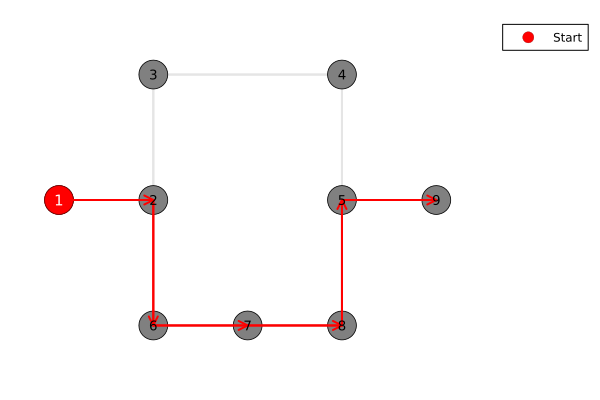

In [50]:
let

    # initialize -
    base_graphmodel = directedgraphmodel;

    # call the flow -
    f = flow(directedgraphmodel, d, p);

    q = plot();
    for (k,v) ∈ base_graphmodel.edgesinverse
       
        # now, get the source,target node index for this edge
        s = v[1];
        t = v[2];
        plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:gray90, lw=2, label="")
    end
    scatter!(node_coordinates[:,1], node_coordinates[:,2], axis=nothing, border=:none, label="", c=:gray, ms=16)
    
    source_node = 1
    target_node = 9
    scatter!([node_coordinates[source_node,1]], [node_coordinates[source_node,2]], 
             c=:red, ms=16, markerstroke=2, markerstrokecolor=:darkred, 
             label="Start")

    # plot path -
    shortest_path_nodes = reconstruct_path(p, 9); # reconstruct the path to the project completion node (9)
    for i in 1:length(shortest_path_nodes)-1
        s = shortest_path_nodes[i]
        t = shortest_path_nodes[i+1]
        plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:red, lw=2, label="")
    end

    n_nodes = size(node_coordinates, 1)
    for i in 1:n_nodes
        x = node_coordinates[i,1]
        y = node_coordinates[i,2]
        if i == 1
            # white text for the red source node
            annotate!(x, y, text(string(i), 10, :white))
        else
            # black text for other nodes
            annotate!(x, y, text(string(i), 9, :black))
        end
    end

    plot!(axis=nothing, border=:none, legend=:outertopright, legendfontsize=8, 
          background_color=:white, xlim=(9.5, 14.5), ylim=(8.5, 11.5))

    current()

end